In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from mlxtend.frequent_patterns import apriori, association_rules

In [3]:
df = pd.read_csv("titanic.csv")  # make sure file is in same folder
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(891, 9)
Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Embarked'],
      dtype='str')
PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         0
dtype: int64


In [8]:
df = df.copy()

# Drop ONLY if exists (prevents KeyError)
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Auto-handle missing values
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [10]:
# Works for ANY Titanic version
target_col = 'Survived' if 'Survived' in df.columns else 'survived'

X = df.drop(target_col, axis=1)
y = df[target_col]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Results")
print(classification_report(y_test, pred_dt))

Decision Tree Results
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179



In [14]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("KNN Results")
print(classification_report(y_test, pred_knn))

KNN Results
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [15]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

pred_best = best_model.predict(X_test)

print("Best Params:", grid.best_params_)
print(classification_report(y_test, pred_best))

Best Params: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



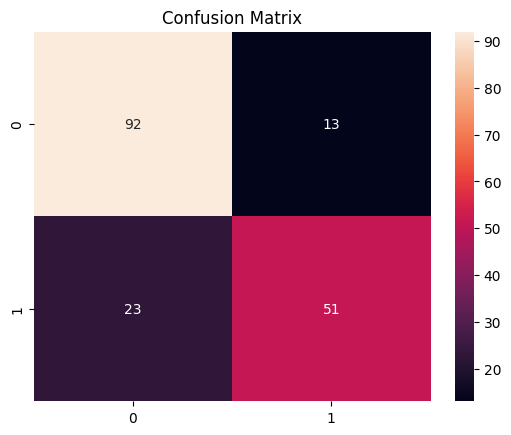

In [16]:
cm = confusion_matrix(y_test, pred_best)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

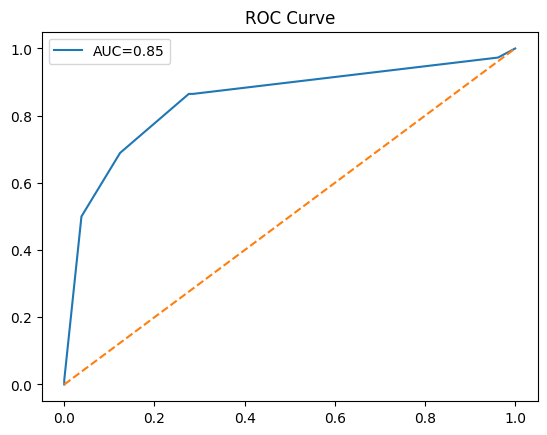

In [17]:
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

df['cluster'] = clusters

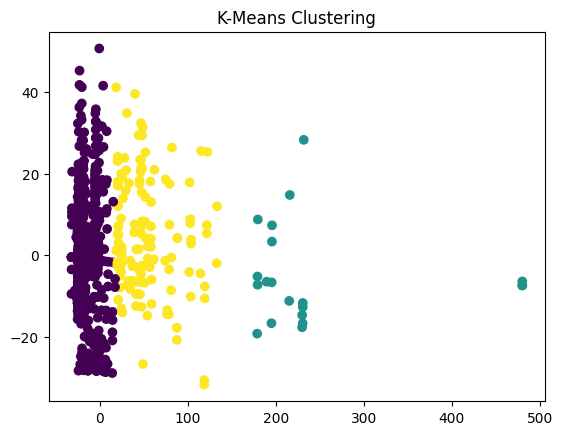

In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("K-Means Clustering")
plt.show()

In [20]:
df_ar = df.copy()

# Convert to binary safely
df_ar = df_ar.apply(lambda x: (x > 0).astype(int))

freq = apriori(df_ar, min_support=0.2, use_colnames=True)

rules = association_rules(freq, metric="lift", min_threshold=1)

rules.head()

/home/mounisha16/myenv/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/home/mounisha16/myenv/lib/python3.12/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Survived}),frozenset({Pclass}),0.383838,1.000000,0.383838,1.000000,1.000000,1.0,0.00000,inf,0.000000,0.383838,0.000000,0.691919
1,frozenset({Pclass}),frozenset({Survived}),1.000000,0.383838,0.383838,0.383838,1.000000,1.0,0.00000,1.000000,0.000000,0.383838,0.000000,0.691919
2,frozenset({Survived}),frozenset({Age}),0.383838,1.000000,0.383838,1.000000,1.000000,1.0,0.00000,inf,0.000000,0.383838,0.000000,0.691919
3,frozenset({Age}),frozenset({Survived}),1.000000,0.383838,0.383838,0.383838,1.000000,1.0,0.00000,1.000000,0.000000,0.383838,0.000000,0.691919
4,frozenset({Survived}),frozenset({Fare}),0.383838,0.983165,0.382716,0.997076,1.014149,1.0,0.00534,5.757576,0.022643,0.388826,0.826316,0.693173
